# Notebook 03: Archivos, análisis y visualización en Python

## SQL para Ciencia de Datos usando Databricks

### Maestría en Ciencia de Datos e Inteligencia de Negocios · Universidad de Antioquia

**Objetivo del notebook:** aplicar operadores lógicos, estructuras de control (condicionales y ciclos), simulaciones numéricas, lectura y escritura de archivos, la librería Pandas y clases en Python como herramientas para el análisis de datos.

- Repositorio fuente: `krushev36/curso-python-r.github.io`
- Archivo original: `sesion3/sesion3python.ipynb`
- Estado: revisado y ordenado para uso en esta ruta del curso.

## Contenido del notebook

1. Operadores lógicos
2. Condicionales
3. Ciclos
4. Series y convergencia
5. Simulación: Random Walk
6. Conjunto de Mandelbrot
7. Escritura de archivos con NumPy
8. Librería OS
9. Lectura de archivos
10. Librería Pandas
11. Clases

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Operadores lógicos

**Contexto:** en cualquier análisis de datos necesitas comparar valores (¿esta venta supera el promedio?, ¿este cliente pertenece a la región X?) y combinar varias condiciones a la vez.

**Necesidad:** sin operadores de comparación y lógicos no es posible expresar reglas de negocio como "si el monto es mayor a 1000 **y** el cliente es de Bogotá". Python ofrece los siguientes operadores para construir esas condiciones:

* Mayor que: `>`
* Mayor o igual que: `>=`
* Igual: `==`
* Menor que: `<`
* Menor o igual que: `<=`
* Y (conjunción): `and`, `&`
* O (disyunción): `or`, `|`

Estos operadores siempre devuelven un valor booleano (`True` o `False`) y son la base de los condicionales y los ciclos que veremos a continuación.

## 2. Condicionales

**Contexto:** muchas decisiones en un análisis dependen de reglas: aprobar o rechazar una transacción, clasificar un cliente como "alto valor" o no, validar credenciales de acceso, etc.

**Necesidad:** los condicionales te permiten ejecutar un bloque de código **solo si** se cumple una condición (o una alternativa distinta si no se cumple), en lugar de ejecutar siempre el mismo flujo de instrucciones.

```python
if condicion:
    instruccion

if condicion:
    instruccion
else:
    instruccion


if condicion:
    instruccion
elif otra_condicion:
    instruccion
else:
    instruccion
```

- `if` evalúa una condición booleana; si es `True`, ejecuta el bloque indentado.
- `else` define qué hacer cuando la condición del `if` es `False`.
- `elif` permite encadenar condiciones adicionales cuando hay más de dos posibles caminos.

### 2.1 Ejemplo: control de acceso con usuario y contraseña
Un caso típico de condicional es validar credenciales antes de dar acceso a un sistema: se comparan los valores ingresados contra los valores esperados y se decide si conceder o negar el acceso.

In [ ]:
# Usuario y contraseña
log = "login"
psswd = 12345

input_log = input("Login: ")
input_psswd = input("password: ")

if (log == input_log) & (psswd == input_psswd):
    print('\naccess granted!')
else:
    print('\nwrong password or username!')

## 3. Ciclos

**Contexto:** al procesar datos (filas de una tabla, elementos de una lista, posiciones de un arreglo) necesitas repetir la misma operación muchas veces sin escribir el código una y otra vez.

**Necesidad:** los ciclos automatizan la repetición de instrucciones sobre una colección de datos (`for`) o mientras se cumpla una condición (`while`), evitando código duplicado y errores de copiar/pegar.

```python
for variable in lista_o_arreglo:
    instruccion


while condicion:
    instruccion

while condicion:
    instruccion
    break       # termina el ciclo inmediatamente
    instruccion
    continue    # salta a la siguiente iteración sin ejecutar el resto del bloque
```

- `for` recorre elemento a elemento una secuencia (lista, arreglo, rango, etc.).
- `while` repite el bloque **mientras** la condición sea verdadera; se debe garantizar que en algún momento se vuelva falsa para evitar un ciclo infinito.
- `break` interrumpe el ciclo por completo; `continue` salta a la siguiente iteración.

### 3.1 Ejemplo: ciclo `for`
Usamos `for` para acumular valores, recorrer índices de un arreglo y recorrer la diagonal de una matriz de NumPy.

In [ ]:
sum = 0
for i in range(8):
    sum = sum + i
    print(sum)

In [ ]:
for i in range(100):
    print('hola '+str(i))

In [ ]:
data = np.random.rand(25).reshape((5,5))
print(data)

print()

for i in range(5):
    print(data[i,i])

### 3.2 Ciclo `while`
A diferencia de `for`, el ciclo `while` no recorre una colección fija: repite el bloque de código mientras la condición evaluada siga siendo verdadera.

In [ ]:
i=0
while i<10:
    print(i)
    i += 1

## 4. Series y convergencia

**Contexto:** en análisis numérico y estadística es común trabajar con sumas de muchos términos (series). Antes de usar una serie en un modelo, conviene verificar si al sumar más y más términos el resultado se estabiliza (converge) o sigue creciendo (diverge).

**Necesidad:** verificar la convergencia "a mano" puede ser complejo. Usando un ciclo `for` y una función que acumule los términos, podemos aproximar numéricamente el comportamiento de una serie con pocas líneas de código.

**Ejemplo:** la función `sum1(n)` calcula la suma parcial de una serie hasta el término `n`. Si al aumentar `n` el resultado deja de cambiar significativamente, la serie converge.

In [ ]:
def sum1(n):
    sum=0
    for i in range(1,n):
        sum += 1./(3.*i - 2.)**(i + 0.5)
    return sum

In [ ]:
sum1(100)

### 4.1 Ejercicio: convergencia de series adicionales
Siguiendo el mismo enfoque de `sum1`, compruebe numéricamente la convergencia de las siguientes series:

$$
\sum^\infty_{n=1} (-1)^n \tanh n
$$


$$
\sum^\infty_{n=1} \frac{(\tan^{-1} n)^2}{n^2+1}
$$

$$
\sum^\infty_{n=2} \frac{\log_n (n!)}{n^3}
$$

### 4.2 Ejercicio: verificación numérica de una identidad
Demuestre numéricamente, para algún valor de `x` con `|x| > 1`, que:
$$
\sum^\infty_{n=1} \frac{n(n+1)}{x^n} = \frac{2x^2}{(1-x)^3}
$$

## 5. Simulación: Random Walk

**Contexto:** muchos fenómenos reales (el precio de una acción, la posición de una partícula, el balance de una cuenta) se modelan como una secuencia de pasos aleatorios a lo largo del tiempo.

**Necesidad:** simular estos procesos permite explorar su comportamiento sin necesidad de datos históricos reales, y es la base de técnicas como Monte Carlo.

Un **random walk** (paseo aleatorio) es un proceso estocástico que describe una trayectoria formada por una sucesión de pasos aleatorios sobre un espacio matemático, por ejemplo los números enteros. El ejemplo más simple es el paseo aleatorio sobre la recta de los enteros $\mathbb{Z}$, que comienza en 0 y en cada paso se mueve +1 o −1 con igual probabilidad.

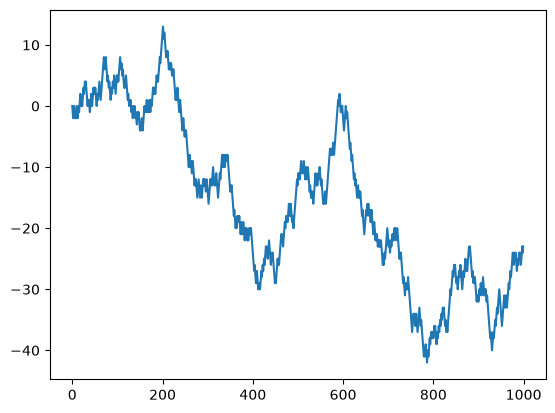

In [3]:
nsize=1000
x = np.zeros(nsize)
y = np.zeros(nsize)

for i in range(1,nsize):
    x[i] = i
    prob = np.random.rand()
    if prob<=0.5:
        y[i] = y[i-1] -1.
    else:
        y[i] = y[i-1] + 1.
        
plt.figure()
plt.plot(x,y)
plt.show()

## 6. Conjunto de Mandelbrot

**Contexto:** este ejemplo combina ciclos anidados, funciones definidas por el usuario y visualización para generar una imagen a partir de un cálculo numérico iterativo, algo común en simulaciones científicas.

**Necesidad:** el conjunto de Mandelbrot ilustra cómo, a partir de una regla matemática muy simple aplicada repetidamente ($z = z^2 + a$), se puede generar un patrón visual complejo. Aquí se usa como ejercicio de programación: recorrer una grilla de valores complejos, contar cuántas iteraciones tarda cada punto en "escapar", y graficar el resultado como una imagen.

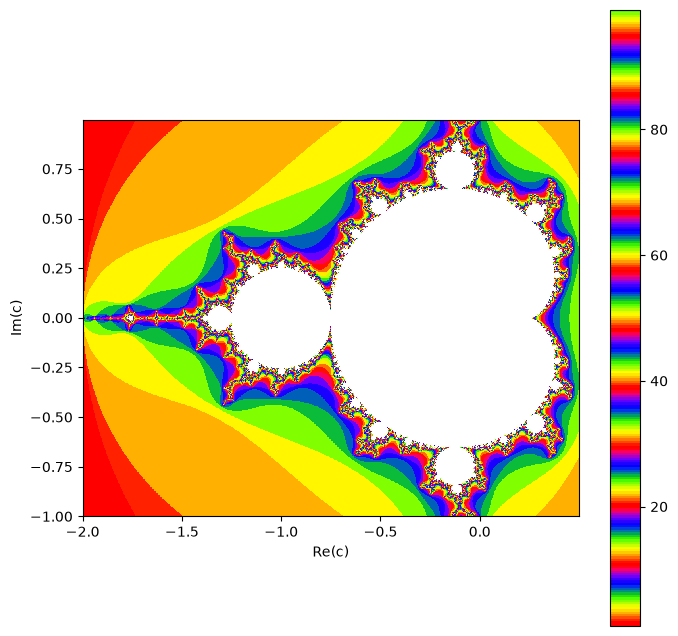

In [2]:
from pylab import *
from numpy import nan
 
def m(a):
    z = 0
    for n in range(1, 100):
        z = z**2 + a
        if abs(z) > 2:
            return n
    return nan
 
X = arange(-2, .5, .002)
Y = arange(-1,  1, .002)
Z = zeros((len(Y), len(X)))
 
for iy, y in enumerate(Y):
    for ix, x in enumerate(X):
        Z[iy,ix] = m(x + 1j * y)
figure(figsize=(8,8))
imshow(Z, cmap = plt.cm.prism, interpolation = 'none', extent = (X.min(), X.max(), Y.min(), Y.max()))
xlabel("Re(c)")
ylabel("Im(c)")
colorbar()
savefig("mandelbrot_python.svg")
show()

## 7. Escritura de archivos con NumPy

**Contexto:** los resultados de un análisis (por ejemplo, la trayectoria del random walk simulado) normalmente necesitan guardarse para reutilizarlos después, compartirlos con otra persona o cargarlos en otra herramienta.

**Necesidad:** NumPy permite guardar arreglos directamente en archivos de texto plano con `np.savetxt()`, sin depender de otra librería, lo que facilita persistir resultados numéricos de forma simple y portable.

In [4]:
x = x.reshape((len(x),1))
y = y.reshape((len(y),1))


data = np.concatenate((x,y),axis=1)
print(data.shape)

np.savetxt('random-walk.tsv',data)

(1000, 2)


## 8. Librería [`os`](https://docs.python.org/3/library/os.html)

**Contexto:** antes de leer o escribir un archivo necesitas saber en qué carpeta estás trabajando, qué archivos existen ahí y, en ocasiones, crear nuevas carpetas para organizar resultados.

**Necesidad:** el módulo `os` ofrece una forma portable (funciona igual en Windows, macOS o Linux) de interactuar con el sistema operativo: consultar el directorio actual, listar archivos, cambiar de carpeta o crear directorios, sin tener que escribir comandos distintos para cada sistema operativo.

Algunas funciones comunes:
- `os.getcwd()`: devuelve el directorio de trabajo actual.
- `os.listdir(ruta)`: lista los archivos y carpetas dentro de una ruta.
- `os.chdir(ruta)` (o `os.fchdir` con un descriptor de archivo): cambia el directorio de trabajo.
- `os.mkdir(ruta)`: crea una nueva carpeta.

In [ ]:
## comandos del os
os.getcwd()

In [ ]:
os.listdir('.')

In [ ]:
os.fchdir("path")

In [ ]:
os.mkdir("path")

## 9. Lectura de archivos

**Contexto:** el análisis de datos casi siempre comienza con la lectura de archivos generados por otros sistemas: registros de ventas, logs, mediciones de sensores, etc.

**Necesidad:** Python ofrece distintas formas de leer un archivo según el nivel de control que necesites: manualmente con `open()`, o de forma más directa con utilidades de NumPy o Pandas.

### 9.1 Lectura de archivos de texto plano
Con `open()` puedes leer un archivo línea por línea y procesar su contenido de forma manual, lo que da control total sobre cómo se interpreta cada línea.

In [ ]:
# Creamos un archivo de texto con dos columnas y varias lineas

file = open('datafile.txt','r')

count=0
for lines in file:
    strings = lines.split(" ")
    print(strings[0]+' '+strings[1])
    count+=1
    
print('total lines: '+str(count))

### 9.2 Lectura de archivos con NumPy
Cuando el archivo contiene datos numéricos en columnas (como el `random-walk.tsv` que generamos en la sección 7), `np.loadtxt()` los carga directamente como un arreglo, evitando el procesamiento manual línea por línea.

In [5]:
newdata = np.loadtxt('random-walk.tsv')

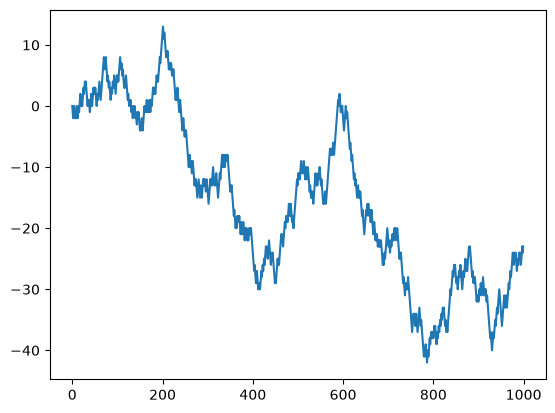

In [6]:
x1, x2 = np.loadtxt('random-walk.tsv', usecols=(0,1),unpack=True, delimiter=' ')


plt.figure()
plt.plot(x1,x2)
plt.show()

## 10. Librería [Pandas](https://pandas.pydata.org/)

**Contexto:** los archivos numéricos simples se pueden leer con NumPy, pero los datos reales suelen mezclar texto, fechas y números en la misma tabla (por ejemplo, un archivo con nombre de cliente, fecha de compra y monto).

**Necesidad:** Pandas es la librería de referencia en Python para análisis de datos tabulares: permite leer archivos con columnas de tipos mixtos, explorar su estructura y calcular estadísticas descriptivas con muy pocas líneas de código, algo mucho más difícil de lograr solo con NumPy.

### 10.1 Lectura de datos con Pandas
`pd.read_csv()` permite cargar un archivo delimitado (no solo `.csv`, también archivos separados por espacios u otros caracteres) directamente como un `DataFrame`, la estructura tabular central de Pandas.

In [7]:
# CREE UN ARCHIVO DE DATOS FORMADO POR COLUMNAS DE DIFERENTES TIPOS DE VARIABLES, STRINGS, INT, FLOATS
import pandas as pd
df = pd.read_csv('datafile2.txt',header=0,sep=" ")

In [8]:
df

,#1.nombre,#2.apellido,#3.cc,#4.edad,#5.hijos,#6.estado
0,juan,perez,12345,20,0,soltero
1,sandra,henao,5642,25,1,casada


In [9]:
df.iloc[:,0]

0      juan
1    sandra
Name: #1.nombre, dtype: str

In [10]:
df.describe()

,#3.cc,#4.edad,#5.hijos
count,2.000000,2.000000,2.000000
mean,8993.500000,22.500000,0.500000
std,4739.736754,3.535534,0.707107
min,5642.000000,20.000000,0.000000
25%,7317.750000,21.250000,0.250000
50%,8993.500000,22.500000,0.500000
75%,10669.250000,23.750000,0.750000
max,12345.000000,25.000000,1.000000


In [11]:
df2 = pd.DataFrame({'lista':np.linspace(1,100,200)}) 
df2.head(3)

,lista
0,1.000000
1,1.497487
2,1.994975


In [ ]:
df2.dtypes

## 11. [Clases](https://docs.python.org/3/tutorial/classes.html)

**Contexto:** hasta ahora hemos trabajado con datos "sueltos" (variables, listas, arreglos) y funciones independientes. Cuando un conjunto de datos y las operaciones que le pertenecen deben viajar siempre juntos —por ejemplo, un "cliente" con su nombre, edad y las acciones que puede realizar—, agruparlos en variables y funciones separadas se vuelve difícil de mantener.

**Necesidad:** una **clase** te permite definir un nuevo tipo de dato propio, combinando datos (atributos) y comportamiento (métodos) en una sola unidad reutilizable. Cada vez que creas una **instancia** de la clase obtienes un objeto independiente con sus propios valores.

El mecanismo de clases de Python agrega este concepto al lenguaje con un mínimo de sintaxis adicional. Como ocurre con los módulos, las clases en Python no imponen una barrera absoluta entre la definición y quien la usa, sino que confían en la buena práctica de no "forzar" el acceso a los datos internos. Aun así, mantienen las características más importantes de la programación orientada a objetos: la herencia permite que una clase derive de una o varias clases base, una clase derivada puede sobreescribir métodos de su clase base, y un método puede invocar al método de la clase base con el mismo nombre.

In [ ]:
class objeto:
    """
    Notas para manual de referencia
    """
    def __init__(self, name,age,gender):
        self.name = name
        self.age = age
        self.gender = gender
    def func(self):
        print('hola mundo')

In [ ]:
# Creamos una instancia (objeto) de la clase
x = objeto("Ana", 28, "F")

In [ ]:
?objeto

In [ ]:
x.name

In [ ]:
x.age